In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
df= pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(1)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['sex'] = df['sex'].map({'male' : 0 , 'female' : 1})
df['smoker'] = df['smoker'].map({'no' : 0 , 'yes' : 1})
df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [8]:
x=df.drop('charges',axis=1)
y = df['charges']

In [9]:
X_train , X_test , y_train, y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [10]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [11]:
rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [12]:
y_pred = rf.predict(X_test)

print(y_pred)

[ 9185.027802   9130.6819365 11990.3052907 42270.0150327  6486.7663301
  9829.2421186 37957.2268228  2238.784653  10140.2785751 11443.7673215
 14071.7422641 24035.1305714 42227.9980171 15042.4135226  5868.9260995
  9021.1938188  6748.3625603 39595.584203   6064.463349   5063.7943079
  3736.7154817 20237.8137195  9780.4343611 21376.8946741 38422.8253036
 17442.2322688 43007.43377   45787.647614  10140.7757921 13075.6045891
  3923.459553   9178.426221   2805.8569585 14949.3079665 47571.7934303
  9742.3891375  8507.7672181  5485.6956436 23193.9500921  9394.1138786
  2105.657648  20958.9046248 41668.6640251  9393.3872795  9354.0135055
  3673.3736992  2290.369532   8089.2107565  8253.3546148 13610.2329584
  5061.3499488  9127.4149871 22180.1044613  6436.1281478  7505.6758199
 11496.8197869 11166.1348234  5729.5649792 41160.9468398  7396.7973099
 10818.9032893  5288.6237175 18274.9660133  1718.863044  14123.8774609
 13811.2890294  7346.2009639 23187.9221028 17160.1158558 17046.9926425
 11626

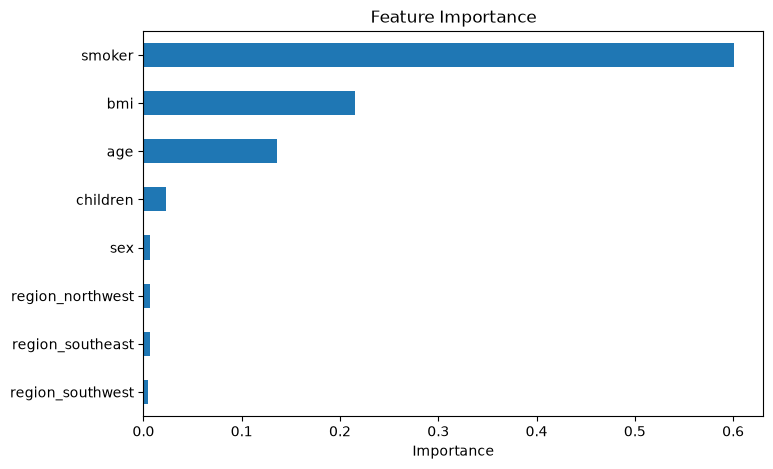

In [18]:
importance = pd.Series(
    rf.feature_importances_,
    index=x.columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()

In [13]:
print("Training Score :", rf.score(X_train, y_train))
print("Testing Score  :", rf.score(X_test, y_test))

Training Score : 0.9737671391059448
Testing Score  : 0.8789930279065968


In [20]:
pickle.dump(rf, open("model.pkl", "wb"))